# Red Neuronal desde Cero con NumPy

En este notebook construiremos una red neuronal **sin usar ningún framework de ML**.
El objetivo es entender exactamente qué ocurre por dentro.

### Arquitectura
```
Entrada (2) → Capa Oculta (4 neuronas, ReLU) → Capa Oculta (4 neuronas, ReLU) → Salida (1, Sigmoid)
```
### Problema
Clasificación binaria: aprenderemos la función **XOR** (no linealmente separable).

---

## 1. Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)
print('Listo')

Listo


## 2. Dataset: Problema XOR extendido

X shape: (200, 2)
y shape: (200, 1)
Clase 0: 104  |  Clase 1: 96


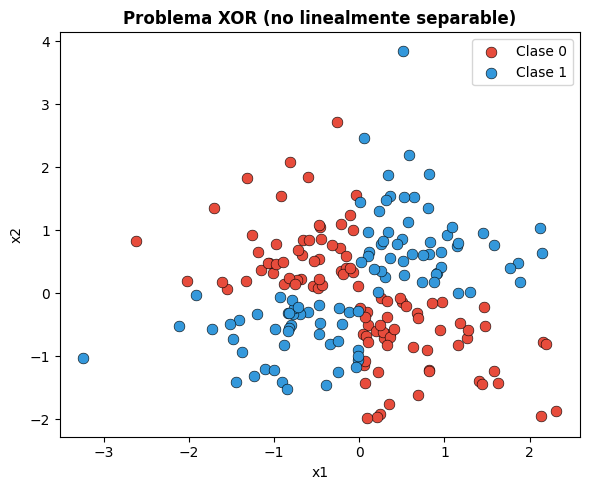

In [2]:
# XOR con ruido para que sea más realista
np.random.seed(42)
n = 200

X = np.random.randn(n, 2)
y = ((X[:, 0] * X[:, 1]) > 0).astype(float).reshape(-1, 1)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Clase 0: {(y==0).sum()}  |  Clase 1: {(y==1).sum()}')

# Visualizar
plt.figure(figsize=(6, 5))
plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1],
            c='#E74C3C', edgecolors='k', linewidths=0.4, s=60, label='Clase 0')
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1],
            c='#3498DB', edgecolors='k', linewidths=0.4, s=60, label='Clase 1')
plt.title('Problema XOR (no linealmente separable)', fontweight='bold')
plt.xlabel('x1'); plt.ylabel('x2')
plt.legend(); plt.tight_layout(); plt.show()

## 3. Funciones de activación
Implementamos **ReLU** y **Sigmoid** con sus derivadas para el backprop.

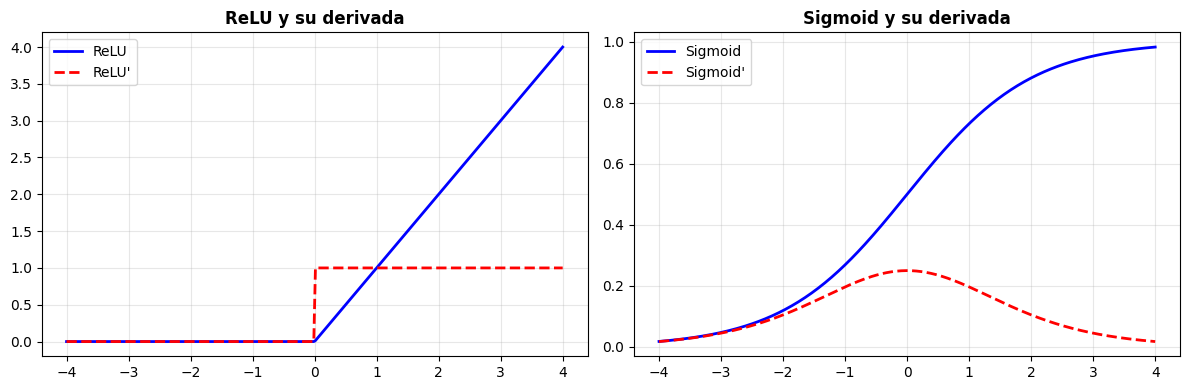

In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

# Visualizar activaciones
z = np.linspace(-4, 4, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z, relu(z), 'b-', linewidth=2, label='ReLU')
axes[0].plot(z, relu_deriv(z), 'r--', linewidth=2, label="ReLU'")
axes[0].set_title('ReLU y su derivada', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(z, sigmoid(z), 'b-', linewidth=2, label='Sigmoid')
axes[1].plot(z, sigmoid_deriv(z), 'r--', linewidth=2, label="Sigmoid'")
axes[1].set_title('Sigmoid y su derivada', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 4. Inicialización de parámetros
Usamos **inicialización He** (recomendada para ReLU) para evitar el problema de gradientes que se desvanecen.

In [4]:
def inicializar_params(capas):
    """
    capas: lista con el número de neuronas por capa.
    Ej: [2, 4, 4, 1] → entrada=2, dos capas ocultas de 4, salida=1
    """
    params = {}
    L = len(capas) - 1

    for l in range(1, L + 1):
        # Inicialización He: sqrt(2 / n_anterior)
        params[f'W{l}'] = np.random.randn(capas[l], capas[l-1]) * np.sqrt(2 / capas[l-1])
        params[f'b{l}'] = np.zeros((capas[l], 1))

    return params

capas = [2, 4, 4, 1]
params = inicializar_params(capas)

for k, v in params.items():
    print(f'{k}: shape={v.shape}')

W1: shape=(4, 2)
b1: shape=(4, 1)
W2: shape=(4, 4)
b2: shape=(4, 1)
W3: shape=(1, 4)
b3: shape=(1, 1)


## 5. Forward Propagation
Calculamos la salida de la red capa por capa: `Z = W·X + b`, luego `A = activación(Z)`

In [5]:
def forward(X, params):
    cache = {'A0': X.T}  # Guardamos activaciones para el backprop
    L = len(params) // 2

    for l in range(1, L + 1):
        W = params[f'W{l}']
        b = params[f'b{l}']
        A_prev = cache[f'A{l-1}']

        Z = W @ A_prev + b
        cache[f'Z{l}'] = Z

        # Última capa → Sigmoid, capas ocultas → ReLU
        if l == L:
            cache[f'A{l}'] = sigmoid(Z)
        else:
            cache[f'A{l}'] = relu(Z)

    y_pred = cache[f'A{L}']
    return y_pred, cache

# Prueba
y_pred_test, _ = forward(X[:5], params)
print('Predicciones iniciales (antes de entrenar):')
print(y_pred_test.flatten().round(4))

Predicciones iniciales (antes de entrenar):
[0.5    0.5001 0.516  0.5176 0.4411]


## 6. Función de pérdida: Binary Cross-Entropy
$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

In [6]:
def binary_cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    eps = 1e-15  # Evitar log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(y_true.T * np.log(y_pred) + (1 - y_true.T) * np.log(1 - y_pred))
    return loss

# Prueba
y_pred_init, _ = forward(X, params)
loss_init = binary_cross_entropy(y, y_pred_init)
print(f'Pérdida inicial (antes de entrenar): {loss_init:.4f}')
print('(Debería estar cerca de ln(2) ≈ 0.693 con pesos aleatorios)')

Pérdida inicial (antes de entrenar): 0.6514
(Debería estar cerca de ln(2) ≈ 0.693 con pesos aleatorios)


## 7. Backpropagation
Calculamos los gradientes usando la regla de la cadena, de atrás hacia adelante.

In [8]:
def backward(y_true, params, cache):
    grads = {}
    m = y_true.shape[0]
    L = len(params) // 2

    # Gradiente de la pérdida respecto a la última activación
    AL = cache[f'A{L}']
    dA = -(y_true.T / AL) + (1 - y_true.T) / (1 - AL)

    for l in range(L, 0, -1):
        Z = cache[f'Z{l}']
        A_prev = cache[f'A{l-1}']

        if l == L:
            dZ = dA * sigmoid_deriv(Z)
        else:
            dZ = dA * relu_deriv(Z)

        grads[f'dW{l}'] = (dZ @ A_prev.T) / m
        grads[f'db{l}'] = np.mean(dZ, axis=1, keepdims=True)
        dA = params[f'W{l}'].T @ dZ

    return grads

print('Backpropagation definido')

Backpropagation definido


## 8. Actualización de parámetros (Gradient Descent)

In [9]:
def actualizar_params(params, grads, lr):
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f'W{l}'] -= lr * grads[f'dW{l}']
        params[f'b{l}'] -= lr * grads[f'db{l}']
    return params

print('Actualización de parámetros definida')

Actualización de parámetros definida


## 9. Entrenamiento completo

In [10]:
def entrenar(X, y, capas, epochs=5000, lr=0.05, verbose=True):
    params = inicializar_params(capas)
    historial = []

    for epoch in range(epochs):
        y_pred, cache = forward(X, params)
        loss = binary_cross_entropy(y, y_pred)
        grads = backward(y, params, cache)
        params = actualizar_params(params, grads, lr)
        historial.append(loss)

        if verbose and epoch % 1000 == 0:
            acc = ((y_pred.flatten() > 0.5) == y.flatten()).mean()
            print(f'Epoch {epoch:5d} | Loss: {loss:.4f} | Accuracy: {acc:.4f}')

    return params, historial

params_entrenados, historial = entrenar(X, y, capas=[2, 4, 4, 1], epochs=5000, lr=0.05)

Epoch     0 | Loss: 0.7144 | Accuracy: 0.5500
Epoch  1000 | Loss: 0.0864 | Accuracy: 0.9850
Epoch  2000 | Loss: 0.0472 | Accuracy: 0.9950
Epoch  3000 | Loss: nan | Accuracy: 0.5200
Epoch  4000 | Loss: nan | Accuracy: 0.5200


C:\Users\Oliver\AppData\Local\Temp\ipykernel_52576\2521658544.py:8: RuntimeWarning: invalid value encountered in divide
  dA = -(y_true.T / AL) + (1 - y_true.T) / (1 - AL)


## 10. Curva de pérdida y frontera de decisión

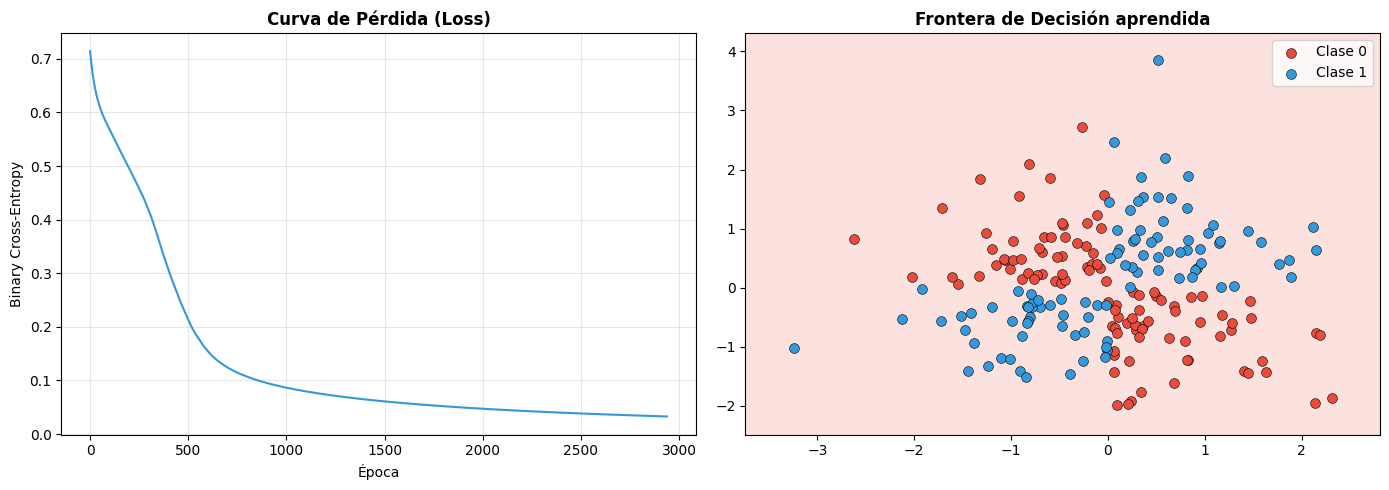


Accuracy final: 52.00%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Curva de pérdida ---
axes[0].plot(historial, color='#3498DB', linewidth=1.5)
axes[0].set_title('Curva de Pérdida (Loss)', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].grid(alpha=0.3)

# --- Frontera de decisión ---
h = 0.05
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

grid = np.c_[xx.ravel(), yy.ravel()]
Z, _ = forward(grid, params_entrenados)
Z = (Z.flatten() > 0.5).reshape(xx.shape)

cmap_bg = ListedColormap(['#FADBD8', '#D6EAF8'])
axes[1].contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.8)
axes[1].scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1],
                c='#E74C3C', edgecolors='k', linewidths=0.4, s=50, label='Clase 0')
axes[1].scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1],
                c='#3498DB', edgecolors='k', linewidths=0.4, s=50, label='Clase 1')
axes[1].set_title('Frontera de Decisión aprendida', fontweight='bold')
axes[1].legend()

plt.tight_layout(); plt.show()

# Accuracy final
y_final, _ = forward(X, params_entrenados)
acc_final = ((y_final.flatten() > 0.5) == y.flatten()).mean()
print(f'\nAccuracy final: {acc_final*100:.2f}%')

## Resumen de lo aprendido

| Componente | Qué hace |
|---|---|
| **Forward Prop** | Calcula la salida propagando la señal hacia adelante |
| **Binary Cross-Entropy** | Mide el error entre predicción y etiqueta real |
| **Backprop** | Calcula gradientes usando la regla de la cadena |
| **Gradient Descent** | Actualiza pesos en dirección contraria al gradiente |
| **ReLU** | Activa neuronas ocultas; evita el problema de gradiente vanishing |
| **Sigmoid** | Convierte la salida en probabilidad (0 a 1) |
| **Init. He** | Inicializa pesos para mantener la varianza estable |

### Ejercicios propuestos
1. Cambia la arquitectura a `[2, 8, 8, 1]` y compara el accuracy.
2. Prueba con `lr=0.5` o `lr=0.001` y observa la curva de pérdida.
3. Implementa **momentum** en la actualización de parámetros.
4. Añade una métrica de **precisión y recall** al entrenamiento.